BERT

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
!pip install accelerate --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import numpy as np
import torch
import evaluate
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [95]:
from torch.utils.tensorboard import SummaryWriter
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
)

In [96]:
sst2_dataset = load_dataset("stanfordnlp/sst2")

def is_valid(example):
    text = example["sentence"].strip()
    cleaned = re.sub(r"[^a-zA-Z0-9]", "", text)
    return len(cleaned) > 0

filtered_train = sst2_dataset["train"].filter(is_valid)
filtered_val = sst2_dataset["validation"].filter(is_valid)

filtered_sst2 = DatasetDict({"train": filtered_train, "validation": filtered_val})
shuffled_data = filtered_sst2.shuffle(seed=42)

small_sst2_dataset = DatasetDict({
    "train": shuffled_data["train"].select(range(0, 1600)),
    "val": shuffled_data["validation"].select(range(0, 320)),
    "test": shuffled_data["validation"].select(range(320, 640)),
})


accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

In [97]:
import os
import torch

def _sanitize_tsv_field(x) -> str:
    return str(x).replace("\t", " ").replace("\n", " ").replace("\r", " ")

@torch.no_grad()
def write_projector_tsvs_for_all_layers(
    *,
    path: str,
    outputs,
    model_inputs,
    tokenizer,
    dataset_split,
    text_col: str = "sentence",
    label_col: str = "label",
    pooling: str = "mean",
):

    os.makedirs(path, exist_ok=True)

    hidden_states = outputs.hidden_states if hasattr(outputs, "hidden_states") else outputs["hidden_states"]

    input_ids = model_inputs["input_ids"]
    attention_mask = model_inputs["attention_mask"].bool()
    special_ids = set(tokenizer.all_special_ids)

    n_layers = len(hidden_states)

    for layer_idx in range(n_layers):
        layer_dir = os.path.join(path, f"layer_{layer_idx}")
        os.makedirs(layer_dir, exist_ok=True)

        layer_h = hidden_states[layer_idx]

        vectors = []
        meta_rows = []

        for i in range(layer_h.shape[0]):
            token_embs = layer_h[i]
            ids_i = input_ids[i]
            am_i = attention_mask[i]

            special_mask = torch.zeros_like(ids_i, dtype=torch.bool)
            for sid in special_ids:
                special_mask |= (ids_i == sid)

            valid_mask = am_i & (~special_mask)

            if valid_mask.sum().item() == 0:
                valid_mask = am_i

            if pooling == "cls":
                first_pos = torch.nonzero(valid_mask, as_tuple=False)[0].item()
                sent_vec = token_embs[first_pos]
            elif pooling == "mean":
                sent_vec = token_embs[valid_mask].mean(dim=0)
            else:
                raise ValueError("pooling must be 'mean' or 'cls'")

            vectors.append(sent_vec.detach().cpu())

            text_val = _sanitize_tsv_field(dataset_split[text_col][i])
            label_val = _sanitize_tsv_field(dataset_split[label_col][i])
            meta_rows.append((text_val, label_val))

        vectors = torch.stack(vectors).numpy()

        emb_path = os.path.join(layer_dir, "embeddings.tsv")
        with open(emb_path, "w", encoding="utf-8") as f:
            for row in vectors:
                f.write("\t".join(f"{x:.6f}" for x in row) + "\n")

        meta_path = os.path.join(layer_dir, "metadata.tsv")
        with open(meta_path, "w", encoding="utf-8") as f:
            f.write("Text\tLabel\n")
            for t, lab in meta_rows:
                f.write(f"{t}\t{lab}\n")

        print(f"[layer {layer_idx}] wrote:\n  {emb_path}\n  {meta_path}")


**BERT**

In [88]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding=True, truncation=True)

small_tokenized_dataset = small_sst2_dataset.map(tokenize_function, batched=True, batch_size=32)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

arguments = TrainingArguments(
    output_dir="bert_sst2_trainer",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    logging_steps=50,
    num_train_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.2e-5,
    weight_decay=0.15,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

In [89]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.704131,0.602570,0.762500
2,0.480019,0.394370,0.837500
3,0.290233,0.360417,0.859375
4,0.232024,0.356645,0.862500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=200, training_loss=0.42660189628601075, metrics={'train_runtime': 69.9969, 'train_samples_per_second': 91.433, 'train_steps_per_second': 2.857, 'total_flos': 185657738438400.0, 'train_loss': 0.42660189628601075, 'epoch': 4.0})

In [90]:
print(trainer.state.best_model_checkpoint)

bert_sst2_trainer/checkpoint-200


In [98]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("bert_sst2_trainer/checkpoint-200")

model_inputs = tokenizer(
    list(small_tokenized_dataset["test"]["sentence"]),
    padding=True,
    truncation=True,
    return_tensors="pt",
)

with torch.no_grad():
    outputs = fine_tuned_model(**model_inputs, output_hidden_states=True, return_dict=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [99]:
write_projector_tsvs_for_all_layers(
    path="results_vis_bert_projector",
    outputs=outputs,
    model_inputs=model_inputs,
    tokenizer=tokenizer,
    dataset_split=small_tokenized_dataset["test"],
    text_col="sentence",
    label_col="label",
    pooling="mean",
)

[layer 0] wrote:
  results_vis_bert_projector/layer_0/embeddings.tsv
  results_vis_bert_projector/layer_0/metadata.tsv
[layer 1] wrote:
  results_vis_bert_projector/layer_1/embeddings.tsv
  results_vis_bert_projector/layer_1/metadata.tsv
[layer 2] wrote:
  results_vis_bert_projector/layer_2/embeddings.tsv
  results_vis_bert_projector/layer_2/metadata.tsv
[layer 3] wrote:
  results_vis_bert_projector/layer_3/embeddings.tsv
  results_vis_bert_projector/layer_3/metadata.tsv
[layer 4] wrote:
  results_vis_bert_projector/layer_4/embeddings.tsv
  results_vis_bert_projector/layer_4/metadata.tsv
[layer 5] wrote:
  results_vis_bert_projector/layer_5/embeddings.tsv
  results_vis_bert_projector/layer_5/metadata.tsv
[layer 6] wrote:
  results_vis_bert_projector/layer_6/embeddings.tsv
  results_vis_bert_projector/layer_6/metadata.tsv
[layer 7] wrote:
  results_vis_bert_projector/layer_7/embeddings.tsv
  results_vis_bert_projector/layer_7/metadata.tsv
[layer 8] wrote:
  results_vis_bert_projector/la

In [100]:
metric = evaluate.load("accuracy")
fine_tuned_model_eval = AutoModelForSequenceClassification.from_pretrained(
    trainer.state.best_model_checkpoint or "bert_sst2_trainer/checkpoint-200"
)

model_inputs_eval = tokenizer(
    list(small_tokenized_dataset["test"]["sentence"]),
    padding=True,
    truncation=True,
    return_tensors="pt",
)

with torch.no_grad():
    outputs_eval = fine_tuned_model_eval(**model_inputs_eval)

predictions = torch.argmax(outputs_eval.logits, dim=-1)
accuracy_result = metric.compute(
    predictions=predictions,
    references=small_tokenized_dataset["test"]["label"],
)
print("BERT Test Accuracy:", accuracy_result)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT Test Accuracy: {'accuracy': 0.884375}


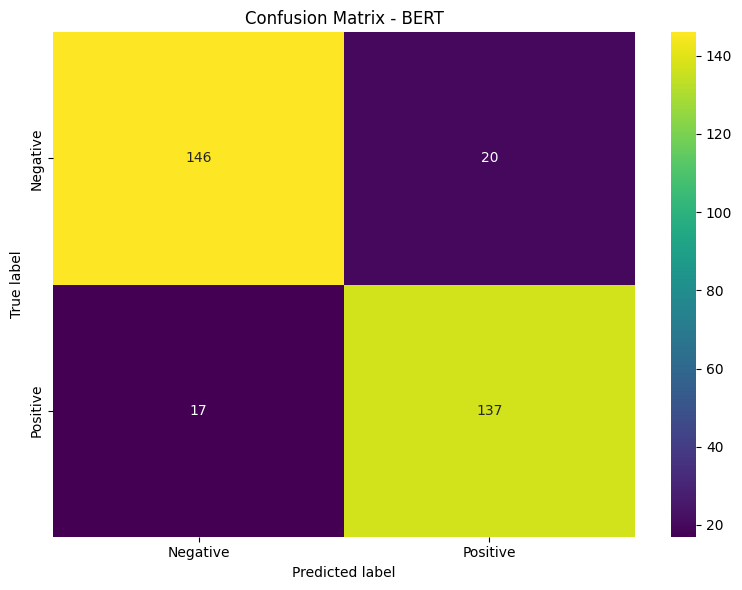

In [ ]:
cm_bert = confusion_matrix(
    small_tokenized_dataset["test"]["label"],
    predictions.numpy()
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Confusion Matrix - BERT')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

**RoBERTa**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding=True, truncation=True)

small_tokenized_dataset = small_sst2_dataset.map(tokenize_function, batched=True, batch_size=32)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
accuracy = evaluate.load("accuracy")

arguments = TrainingArguments(
    output_dir="roberta_sst2_trainer",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    logging_steps=50,
    num_train_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    weight_decay=0.08,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.689045,0.679057,0.521875
2,0.475615,0.338702,0.881250
3,0.268642,0.323918,0.890625
4,0.243604,0.321272,0.890625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=200, training_loss=0.41922625064849856, metrics={'train_runtime': 77.1763, 'train_samples_per_second': 82.927, 'train_steps_per_second': 2.591, 'total_flos': 192103959294720.0, 'train_loss': 0.41922625064849856, 'epoch': 4.0})

In [ ]:
print(trainer.state.best_model_checkpoint)

roberta_sst2_trainer/checkpoint-150


In [101]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("roberta_sst2_trainer/checkpoint-150")

model_inputs = tokenizer(
    list(small_tokenized_dataset["test"]["sentence"]),
    padding=True,
    truncation=True,
    return_tensors="pt",
)

with torch.no_grad():
    outputs = fine_tuned_model(**model_inputs, output_hidden_states=True, return_dict=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [102]:
write_projector_tsvs_for_all_layers(
    path="results_vis_roberta_projector",
    outputs=outputs,
    model_inputs=model_inputs,
    tokenizer=tokenizer,
    dataset_split=small_tokenized_dataset["test"],
    text_col="sentence",
    label_col="label",
    pooling="mean",
)

[layer 0] wrote:
  results_vis_roberta_projector/layer_0/embeddings.tsv
  results_vis_roberta_projector/layer_0/metadata.tsv
[layer 1] wrote:
  results_vis_roberta_projector/layer_1/embeddings.tsv
  results_vis_roberta_projector/layer_1/metadata.tsv
[layer 2] wrote:
  results_vis_roberta_projector/layer_2/embeddings.tsv
  results_vis_roberta_projector/layer_2/metadata.tsv
[layer 3] wrote:
  results_vis_roberta_projector/layer_3/embeddings.tsv
  results_vis_roberta_projector/layer_3/metadata.tsv
[layer 4] wrote:
  results_vis_roberta_projector/layer_4/embeddings.tsv
  results_vis_roberta_projector/layer_4/metadata.tsv
[layer 5] wrote:
  results_vis_roberta_projector/layer_5/embeddings.tsv
  results_vis_roberta_projector/layer_5/metadata.tsv
[layer 6] wrote:
  results_vis_roberta_projector/layer_6/embeddings.tsv
  results_vis_roberta_projector/layer_6/metadata.tsv
[layer 7] wrote:
  results_vis_roberta_projector/layer_7/embeddings.tsv
  results_vis_roberta_projector/layer_7/metadata.tsv


In [ ]:
metric = evaluate.load("accuracy")
fine_tuned_model_eval = AutoModelForSequenceClassification.from_pretrained(
    trainer.state.best_model_checkpoint or "roberta_sst2_trainer/checkpoint-150"
)

model_inputs_eval = tokenizer(
    list(small_tokenized_dataset["test"]["sentence"]),
    padding=True,
    truncation=True,
    return_tensors="pt",
)

with torch.no_grad():
    outputs_eval = fine_tuned_model_eval(**model_inputs_eval)

predictions = torch.argmax(outputs_eval.logits, dim=-1)
accuracy_result = metric.compute(
    predictions=predictions,
    references=small_tokenized_dataset["test"]["label"],
)

print("RoBERTa Test Accuracy:", accuracy_result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa Test Accuracy: {'accuracy': 0.909375}


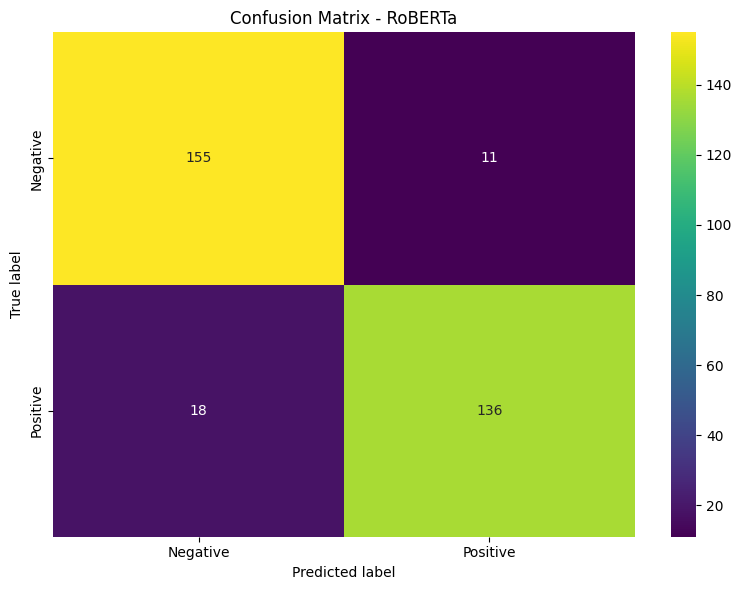

In [ ]:
cm_roberta = confusion_matrix(
    small_tokenized_dataset["test"]["label"],
    predictions.numpy()
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_roberta,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Confusion Matrix - RoBERTa')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()